## Importation

In [65]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
import numpy as np

## preprocessing 

In [66]:
df = pd.read_csv(r"C:\\Users\\semy4\\OneDrive\\Bureau\\Fintech_project\\data\\raw\\dataset_finance_hybride_2010_2026.csv")

In [49]:
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,StockChange
0,2010-01-04,GOOGL,15.551540,15.615042,15.484320,15.546579,78169752,-0.000319
1,2010-01-05,GOOGL,15.557246,15.573617,15.417345,15.478117,120067812,-0.005086
2,2010-01-06,GOOGL,15.524502,15.524502,15.040803,15.087933,158988852,-0.028121
3,2010-01-07,GOOGL,15.116211,15.131095,14.700727,14.736693,256315428,-0.025107
4,2010-01-08,GOOGL,14.684602,14.963659,14.612915,14.933149,188783028,0.016926


In [50]:
df.columns.tolist()

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'StockChange']

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36971 entries, 0 to 36970
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         36971 non-null  object 
 1   Ticker       36971 non-null  object 
 2   Open         36971 non-null  float64
 3   High         36971 non-null  float64
 4   Low          36971 non-null  float64
 5   Close        36971 non-null  float64
 6   Volume       36971 non-null  int64  
 7   StockChange  36971 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.3+ MB


In [52]:
df.isnull().sum()

Date           0
Ticker         0
Open           0
High           0
Low            0
Close          0
Volume         0
StockChange    0
dtype: int64

In [53]:
df.shape

(36971, 8)

In [54]:
doublons_totaux = df.duplicated().sum()
print(f"Nombre de lignes totalement dupliquées : {doublons_totaux}")

Nombre de lignes totalement dupliquées : 0


In [55]:
doublons_logiques = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f" Nombre de cotations en double pour une même journée/action : {doublons_logiques}")

 Nombre de cotations en double pour une même journée/action : 0


In [56]:
print(" Statistiques descriptives des rendements :")

display(df[['Open', 'Close', 'Volume', 'StockChange']].describe().round(4))

 Statistiques descriptives des rendements :


,Open,Close,Volume,StockChange
count,36971.0000,36971.0000,3.697100e+04,36971.0000
mean,143.8427,143.8591,5.950398e+07,0.0003
std,141.5972,141.5728,1.016001e+08,0.0164
min,1.0760,1.0533,6.720000e+04,-0.1975
25%,29.9051,29.9478,9.856250e+06,-0.0076
50%,96.9300,97.0170,2.892240e+07,0.0003
75%,208.4950,208.6150,6.851200e+07,0.0083
max,788.5654,787.4192,1.880998e+09,0.2574


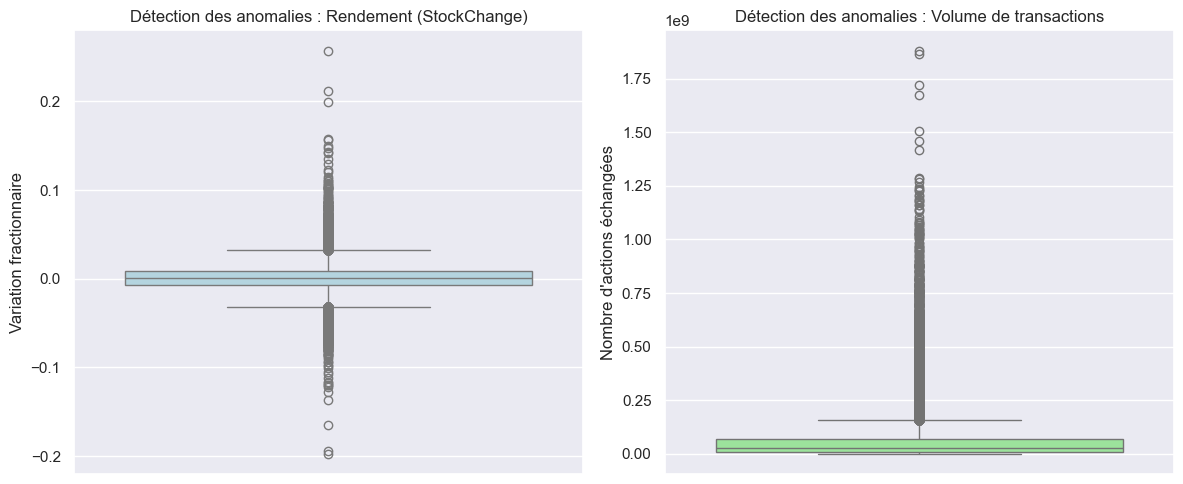

In [57]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.boxplot(y=df['StockChange'], color='lightblue')
plt.title('Détection des anomalies : Rendement (StockChange)')
plt.ylabel('Variation fractionnaire')


plt.subplot(1, 2, 2)
sns.boxplot(y=df['Volume'], color='lightgreen')
plt.title('Détection des anomalies : Volume de transactions')
plt.ylabel('Nombre d\'actions échangées')

plt.tight_layout()
plt.show()

## 📊 Étape 2 : Analyse Exploratoire des Données (EDA) Financières

Maintenant que nos données sont propres et que notre variable `StockChange` est calculée, nous passons à l'analyse exploratoire (EDA).

**Objectifs de cette section :**
1. **Étude statistique :** Analyser la moyenne, la variance et la distribution de notre rendement intra-journalier (`StockChange`).
2. **Visualisation :** Observer l'évolution historique des prix et comparer la volatilité des différentes actions.

Lancement de l'Analyse Exploratoire (EDA) Financière...

Résumé Statistique du Rendement Intra-journalier (StockChange) :


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,4188.0,0.0005,0.0140,-0.0765,-0.0070,0.0007,0.0084,0.1564
AMZN,4188.0,0.0002,0.0162,-0.0856,-0.0088,0.0000,0.0097,0.1222
BRK-B,4188.0,-0.0001,0.0096,-0.0540,-0.0052,-0.0000,0.0051,0.0647
GOOGL,4188.0,0.0003,0.0133,-0.0801,-0.0069,0.0003,0.0078,0.0989
JPM,4188.0,0.0003,0.0132,-0.0599,-0.0065,0.0006,0.0071,0.1028
META,3589.0,0.0002,0.0181,-0.0908,-0.0096,0.0003,0.0104,0.1502
MSFT,4188.0,0.0004,0.0126,-0.0592,-0.0064,0.0005,0.0076,0.1045
TSLA,4066.0,0.0003,0.0295,-0.1975,-0.0155,-0.0001,0.0163,0.2574
UNH,4188.0,0.0005,0.0139,-0.0774,-0.0071,0.0006,0.0080,0.0913


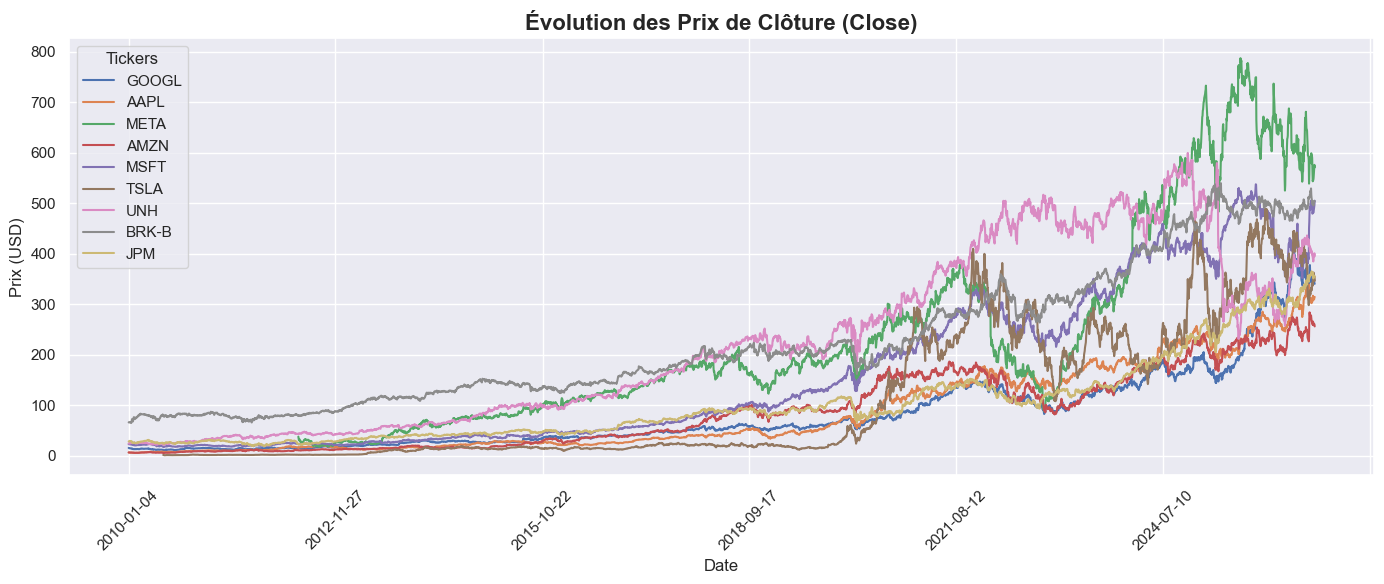

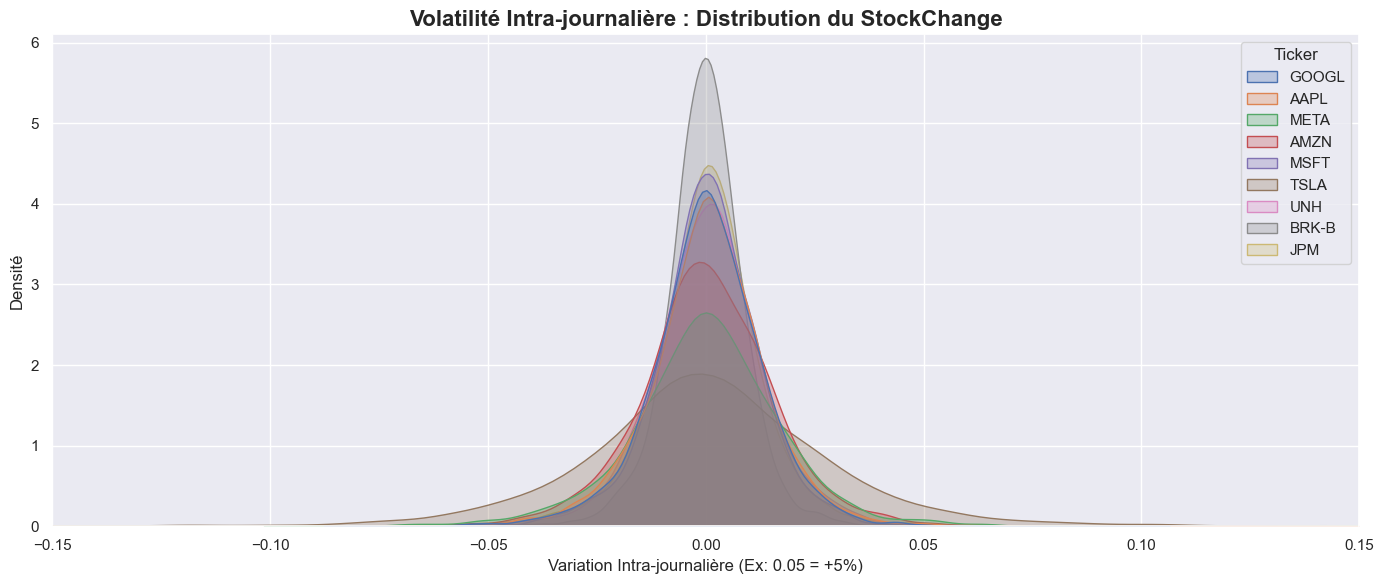

In [67]:
print("Lancement de l'Analyse Exploratoire (EDA) Financière...")

print("\nRésumé Statistique du Rendement Intra-journalier (StockChange) :")
display(df.groupby('Ticker')['StockChange'].describe().round(4))



plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Close', hue='Ticker', linewidth=1.5)
plt.title("Évolution des Prix de Clôture (Close)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Prix (USD)", fontsize=12)
plt.legend(title="Tickers")


plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



plt.figure(figsize=(14, 6))
sns.kdeplot(data=df, x='StockChange', hue='Ticker', fill=True, alpha=0.3)
plt.title("Volatilité Intra-journalière : Distribution du StockChange", fontsize=16, fontweight='bold')
plt.xlabel("Variation Intra-journalière (Ex: 0.05 = +5%)", fontsize=12)
plt.ylabel("Densité", fontsize=12)


plt.xlim(-0.15, 0.15) 

plt.tight_layout()
plt.show()

### 💡 Conclusion Stratégique de l'Analyse Exploratoire Financière

L'inspection visuelle et statistique de nos séries temporelles révèle des dynamiques de marché cruciales qu'il faudra garder à l'esprit lors de l'évaluation de notre modèle IA. 

**1. Deux régimes de marché distincts (Tendance Macro)**
L'historique des prix (2010-2026) met en évidence un contraste saisissant entre deux catégories d'actifs :
* **Les actions défensives et "Valeur" (BRK-B, UNH, JPM) :** Elles affichent une croissance linéaire, stable et résiliente, même durant les périodes de crise.
* **Les valeurs "Tech & Hyper-croissance" (TSLA, META) :** Elles sont le moteur de la hausse globale, particulièrement durant le super-cycle de l'IA (2023-2026), mais au prix d'une volatilité historique extrême (ex: le krach puis rebond spectaculaire de META).

**2. La radiographie du risque (Volatilité Intra-journalière)**
La distribution des densités (KDE) du `StockChange` confirme mathématiquement ces profils :
* **Les marchés efficients et calmes :** La courbe de Berkshire Hathaway (BRK-B) présente un pic central très resserré. L'écrasante majorité de ses journées se solde par un rendement proche de 0%. 
* **Les marchés irrationnels (Fat Tails) :** Tesla (TSLA) et Meta (META) présentent des "queues épaisses". Leurs courbes s'étalent largement, ce qui prouve que ces actifs subissent très fréquemment des variations intra-journalières massives (au-delà de ±5%).

> **🧠 Impact direct sur la modélisation NLP (FinBERT)**
> Ces observations suggèrent que notre stratégie hybride ne sera pas uniformément efficace. L'analyse de sentiment (basée sur l'humeur des réseaux sociaux et de la presse) devrait logiquement obtenir de **bien meilleurs scores de corrélation sur les actions "émotionnelles"** (TSLA, META), où l'actualité provoque des réactions boursières épidermiques. À l'inverse, le signal d'Alpha risque d'être beaucoup plus faible sur des actions institutionnelles (BRK-B), hermétiques au "bruit" médiatique.

---
**➡️ Prochaine Étape :** La Grande Fusion (Inner Join) entre ce jeu de données financières et les signaux de sentiment générés par FinBERT.

In [68]:
## creation de la target (CORRECTE - Intraday Open -> Close)

# StockChange = (Close - Open) / Open  → déjà calculé dans dataset_finance_hybride
# Target = 1 si StockChange > 0 (hausse intraday), 0 sinon

df['Target'] = (df['StockChange'] > 0).astype(int)  # 1 = hausse intraday, 0 = baisse/stable

# Vérification cohérence parfaite
check = ((df['StockChange'] > 0) & (df['Target'] == 1)) | \
        ((df['StockChange'] <= 0) & (df['Target'] == 0))
print(f"Cohérence StockChange ↔ Target: {check.all()} (doit être True)")

print(f"\nDistribution Target:")
print(df['Target'].value_counts())
print(f"% Hausse (1): {df['Target'].mean():.1%}")

Cohérence StockChange ↔ Target: True (doit être True)

Distribution Target:
Target
1    18891
0    18080
Name: count, dtype: int64
% Hausse (1): 51.1%


In [69]:
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,StockChange,Target
0,2010-01-04,GOOGL,15.551540,15.615042,15.484320,15.546579,78169752,-0.000319,0
1,2010-01-05,GOOGL,15.557246,15.573617,15.417345,15.478117,120067812,-0.005086,0
2,2010-01-06,GOOGL,15.524502,15.524502,15.040803,15.087933,158988852,-0.028121,0
3,2010-01-07,GOOGL,15.116211,15.131095,14.700727,14.736693,256315428,-0.025107,0
4,2010-01-08,GOOGL,14.684602,14.963659,14.612915,14.933149,188783028,0.016926,1


In [70]:
df['Date'] = pd.to_datetime(df['Date'])

df_bourse_2023_2026 = df[(df['Date'].dt.year >= 2023) & (df['Date'].dt.year <= 2026)].copy()

print(f"📉 Lignes avant filtrage (2010-2026) : {len(df)}")
print(f"✅ Lignes conservées (2023-2026) : {len(df_bourse_2023_2026)}")

print(f"\n📅 Date de début : {df_bourse_2023_2026['Date'].min().date()}")
print(f"📅 Date de fin   : {df_bourse_2023_2026['Date'].max().date()}")

display(df_bourse_2023_2026.head())

📉 Lignes avant filtrage (2010-2026) : 36971
✅ Lignes conservées (2023-2026) : 8244

📅 Date de début : 2023-01-03
📅 Date de fin   : 2026-08-27


,Date,Ticker,Open,High,Low,Close,Volume,StockChange,Target
3272,2023-01-03,GOOGL,88.802555,90.249730,87.741960,88.336693,28131200,-0.005246,0
3273,2023-01-04,GOOGL,89.555892,89.853259,86.502961,87.305847,34854800,-0.025124,0
3274,2023-01-05,GOOGL,86.701194,86.800314,85.144994,85.442352,27194400,-0.014519,0
3275,2023-01-06,GOOGL,86.027181,86.919272,84.114144,86.572342,41381500,0.006337,1
3276,2023-01-09,GOOGL,87.583376,89.258525,87.087771,87.246361,29003900,-0.003848,0


In [71]:
## création d'une nouvelle feature Daily_Volatility et suppression des colonnes colinéaires 
# 1. Création de la variable de Volatilité Intraday
df['Daily_Volatility'] = (df['High'] - df['Low']) / df['Open']

# 2. Suppression des colonnes de prix bruts (Multicolinéaires et non-stationnaires)
df.drop(columns=['Open', 'High', 'Low', 'Close'], inplace=True)

# 3. Vérification de la nouvelle structure du DataFrame
print("--- Nouvelles colonnes du dataset ---")
print(df.columns.tolist())

# Aperçu des premières lignes pour valider le résultat
display(df.head())

--- Nouvelles colonnes du dataset ---
['Date', 'Ticker', 'Volume', 'StockChange', 'Target', 'Daily_Volatility']


,Date,Ticker,Volume,StockChange,Target,Daily_Volatility
0,2010-01-04,GOOGL,78169752,-0.000319,0,0.008406
1,2010-01-05,GOOGL,120067812,-0.005086,0,0.010045
2,2010-01-06,GOOGL,158988852,-0.028121,0,0.031157
3,2010-01-07,GOOGL,256315428,-0.025107,0,0.028471
4,2010-01-08,GOOGL,188783028,0.016926,1,0.023885


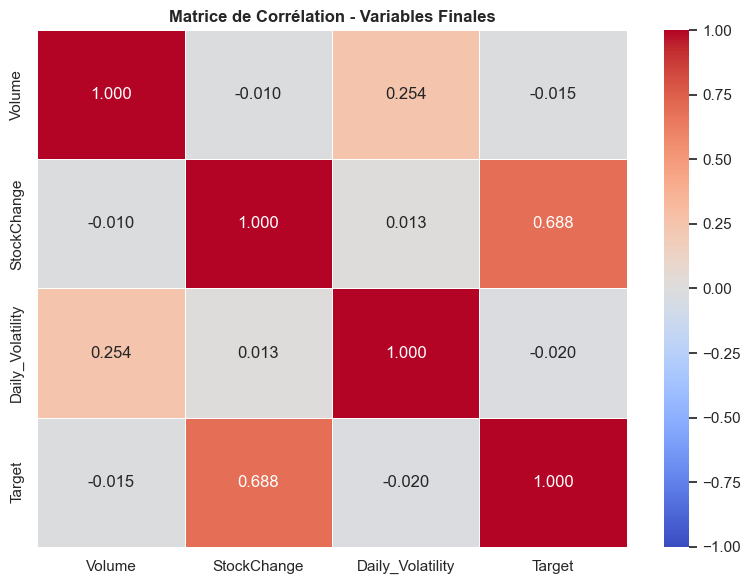

,Volume,StockChange,Daily_Volatility,Target
Volume,1.000000,-0.010043,0.253781,-0.014774
StockChange,-0.010043,1.000000,0.012787,0.688194
Daily_Volatility,0.253781,0.012787,1.000000,-0.019933
Target,-0.014774,0.688194,-0.019933,1.000000


In [72]:
## création d'une matrice de corrélation pour voir les relations entre les variables
colonnes_numeriques = ['Volume', 'StockChange', 'Daily_Volatility', 'Target']
matrice_corr_finale = df[colonnes_numeriques].corr()


# Configuration et affichage de la Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr_finale, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice de Corrélation - Variables Finales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Affichage des valeurs en console
display(matrice_corr_finale)

In [74]:

df['Date'] = pd.to_datetime(df['Date'])

date_debut = '2023-01-01'
date_fin = '2026-12-31'
df_filtre = df[(df['Date'] >= date_debut) & (df['Date'] <= date_fin)].copy()

print(f" Lignes avant filtrage : {len(df)} | Lignes après filtrage (2023-2026) : {len(df_filtre)}")

print(" Tri chronologique des données par Ticker et Date...")
df_bourse_2023_2026 = df_filtre.sort_values(by=['Ticker', 'Date'], ascending=[True, True])

dossier_sauvegarde = r"C:\\Users\\semy4\\OneDrive\\Bureau\\Fintech_project\\data\\processed"
nom_fichier = "FINANCE_2023_2026_Well_Prepared.csv"
chemin_complet = os.path.join(dossier_sauvegarde, nom_fichier)

df_bourse_2023_2026.to_csv(chemin_complet, index=False)

print(f" Fichier prêt et sauvegardé avec succès ici :\n {chemin_complet}")
display(df_bourse_2023_2026.head())

 Lignes avant filtrage : 36971 | Lignes après filtrage (2023-2026) : 8244
 Tri chronologique des données par Ticker et Date...
 Fichier prêt et sauvegardé avec succès ici :
 C:\\Users\\semy4\\OneDrive\\Bureau\\Fintech_project\\data\\processed\FINANCE_2023_2026_Well_Prepared.csv


,Date,Ticker,Volume,StockChange,Target,Daily_Volatility
7460,2023-01-03,AAPL,112117500,-0.039991,0,0.051658
7461,2023-01-04,AAPL,89113600,-0.004177,0,0.028213
7462,2023-01-05,AAPL,80962700,-0.016597,0,0.023677
7463,2023-01-06,AAPL,87754700,0.028648,1,0.042854
7464,2023-01-09,AAPL,70790800,-0.002453,0,0.026979
